# Assignment 1 - Pandas and Plotting

In [39]:
!pip install -r requirements.txt


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
    --------------------------------------- 0.3/12.5 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.5 MB 2.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/12.5 MB 3.7 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/12.5 MB 4.6 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.5 MB 4.7 MB/s eta 0:00:02
   ------------------ --------------------- 5.8/12.5 MB 5.2 MB/s eta 0:00:02
   ------------------------ --------------- 7.6/12.5 MB 5.9 MB/s eta 0:00:01
   ------------------------------- -------- 9.7/12.5 MB 6.4 MB/s eta 0:00:01
   ------------------------------------- -- 11.5/12.5 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.5 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 12.5/12.5 MB 6.4 MB/s eta 0:00:00
   --------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
seleniumbase 4.32.7 requires h11==0.14.0, but you have h11 0.16.0 which is incompatible.


In [5]:
# Required Libraries 
import numpy as np
import pandas as pd

# Acquiring the data 
import data_preparation as data_prep
from ucimlrepo import fetch_ucirepo

## Data Preperation

Run this cell to download the dataset into `data` folder.

In [6]:
data_prep.get_heart_disease_content()

## Introduction to Pandas


Create a list of heart-disease dataset column names using `x=heart_disease.features` and `y=heart_disease.data.targets`.

In [14]:
## Initial Configuration
heart_disease = fetch_ucirepo(id=45)

## Defining the data repartition: Getting the two primary components directly:
X = heart_disease.data.features
y = heart_disease.data.targets

    project/
    │
    ├── data_preparation.py
    │
    └── data/
        ├── heart_disease.csv
        ├── heart_disease_features.csv
        ├── heart_disease_targets.csv
        └── heart_disease_variables.csv


Attention to the following.

- Show only a portion of the dataset. Use `head`, `tail`, or `sample` functions whenever possible.

In [15]:
col_name=['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','num']

Read `data/heart_disease.csv` into dataframe. Ensure your dataset has column names.

In [16]:
heart_disease = pd.read_csv("data/heart_disease.csv", sep=",")


Show first two rows.

In [17]:
heart_disease.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2


Show the data shape.

In [18]:
heart_disease.shape

(303, 14)

Show number of values for each `sex` type.

In [19]:
len(heart_disease.groupby(['sex']))

2

In [21]:
heart_disease['sex'].value_counts()

sex
1    206
0     97
Name: count, dtype: int64

Show statistics on `chol` column.

In [22]:
heart_disease['chol'].describe()

count    303.000000
mean     246.693069
std       51.776918
min      126.000000
25%      211.000000
50%      241.000000
75%      275.000000
max      564.000000
Name: chol, dtype: float64

In [23]:
#OR we can use
heart_disease.agg({"chol": ["min", "max", "median", "skew", "mean", "std"]})

,chol
min,126.000000
max,564.000000
median,241.000000
skew,1.135503
mean,246.693069
std,51.776918


Filter dataset by people who has fasting blood sugar (`fbs`) more than 120 mg/dl.

In [24]:
'''
fbs: (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)
'''
heart_disease[heart_disease['fbs'].values == 1].head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


Show number of different chest pain type (`cp`) for **females** who has exercise induced angina (`exang`). 

In [25]:
'''     sex: sex (1 = male; 0 = female)
        **********************************************
        Chest Pain
        cp: chest pain type
        -- Value 1: typical angina
        -- Value 2: atypical angina
        -- Value 3: non-anginal pain
        -- Value 4: asymptomatic
        **********************************************
        exang
        exang: exercise induced angina (1 = yes; 0 = no)

'''
      
heart_disease[(heart_disease.sex == 0) & (heart_disease.exang == 1)].cp.count()

np.int64(22)

Show only `age`, `sex` and `num` for people who has serum cholestoral (`chol`) more than 200 mg/dl.

In [26]:
heart_disease[heart_disease.chol>200][['age', 'sex', 'num']].head(5)

,age,sex,num
0,63,1,0
1,67,1,2
2,67,1,1
3,37,1,0
4,41,0,0


In [27]:
#OR
heart_disease.iloc[:,list(range(2)) +[-1]][heart_disease.chol>200].head(5)

,age,sex,num
0,63,1,0
1,67,1,2
2,67,1,1
3,37,1,0
4,41,0,0


Show only rows between 10 to 25 and columns `age`, `chol`, `slope` and `thal`.

In [28]:
heart_disease.iloc[list(range(10,25)),:][['age', 'chol', 'slope','thal']]

,age,chol,slope,thal
10,57,192,2,6.0
11,56,294,2,3.0
12,56,256,2,6.0
13,44,263,1,7.0
14,52,199,1,7.0
15,57,168,1,3.0
16,48,229,3,7.0
17,54,239,1,3.0
18,48,275,1,3.0
19,49,266,1,3.0


Show rows 0, 2, 4, 6, and 8 with column indexes 2, 3, 5, and -1.

In [29]:
heart_disease.head(10)
heart_disease.iloc[list(range(0,10,2)),:].iloc[:,list([2,3,5,-1])]

,cp,trestbps,fbs,num
0,1,145,1,0
2,4,120,0,1
4,2,130,0,0
6,4,140,0,3
8,4,130,0,2


Find the mean of serum cholestoral (`chol`) of the dataset.

In [32]:
print(round(heart_disease.chol.mean(),2))

246.69


Find the mean of serum cholestoral (`chol`) of each different `sex` and `cp` groups.

In [33]:
heart_disease.groupby(['sex','cp']).chol.mean().round(2)

sex  cp
0    1     247.00
     2     251.44
     3     261.06
     4     268.48
1    1     235.05
     2     241.03
     3     232.24
     4     243.61
Name: chol, dtype: float64

Find the min, mean, and max of serum cholestoral (`chol`) of each different `sex` and `cp` groups.

In [34]:
heart_disease.groupby(['sex','cp']).agg({"chol": ["min", "mean", "max"]}).round(2)

chol             
        min    mean  max
sex cp                  
0   1   226  247.00  283
    2   160  251.44  342
    3   141  261.06  564
    4   149  268.48  409
1   1   182  235.05  298
    2   157  241.03  325
    3   126  232.24  335
    4   131  243.61  353

Find min of `chol`, max of `thalach`, second highest of `trestbps` of each different `sex` and `cp` groups.

In [35]:
'''
finding second largest
'''
df = heart_disease.trestbps
first_highest_value_index = df.idxmax()
second_highest_value_index = df.replace(df.max(),df.min()).idxmax()

first_highest_value = df[first_highest_value_index]
second_highest_value = df[second_highest_value_index]

#-----

heart_disease.groupby(['sex','cp']).agg({"chol": ["min"], "thalach": ["max"],"trestbps": list(["max"])[-1]}).round(2)

chol thalach trestbps
        min     max      max
sex cp                      
0   1   226     171      150
    2   160     192      160
    3   141     179      160
    4   149     182      200
1   1   182     190      178
    2   157     202      192
    3   126     194      180
    4   131     186      170

## Plotting with Pandas

 Use heart_disease dataframe while plotting.

In [40]:
import matplotlib as plt 
plots = []

Plot column `sex` with a bar chart.

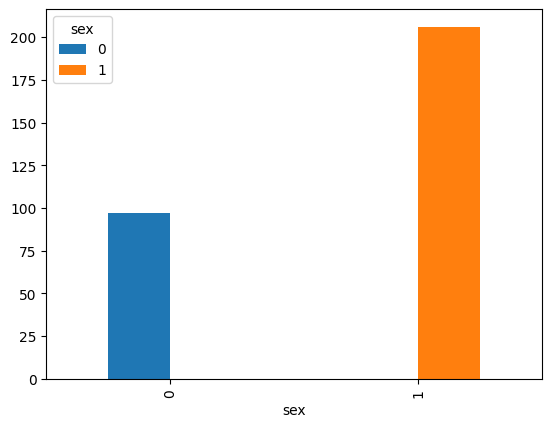

In [41]:
sexplot = pd.crosstab(heart_disease['sex'],heart_disease['sex']).plot.bar(orientation='vertical')
'''
This second part is reserved for future fig export
'''

fig = sexplot.get_figure()
plots.append(fig)

Plot column `cp` with a horizontal bar chart.

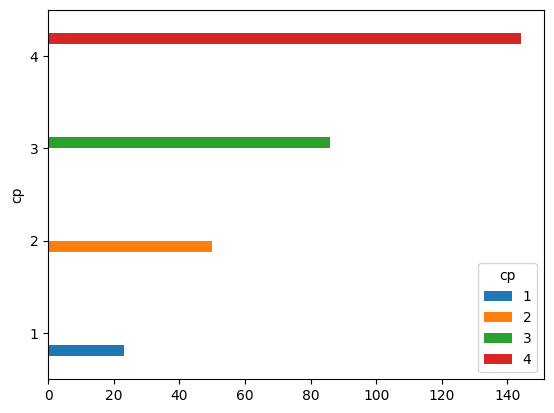

In [42]:
cpplot= pd.crosstab(heart_disease['cp'],heart_disease['cp']).plot.barh()
'''
This second part is reserved for future fig export
'''
fig1 = cpplot.get_figure()
plots.append(fig1)

Plot column `chol` and `thalach` with a scatter chart. 

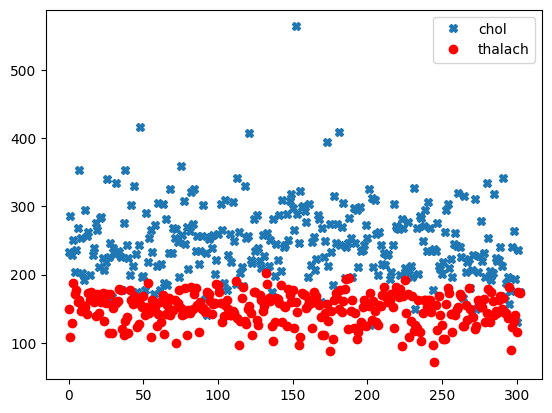

In [43]:
df2= heart_disease[['chol','thalach']]
cholthalachplot= df2.plot(style=['X','ro'])
'''
This second part is reserved for future fig export
'''
fig3 = cholthalachplot.get_figure()
plots.append(fig3)

Plot column `chol` and `thalach` with a line chart. Use records **only** females who has exercise induced angina (`exang`).

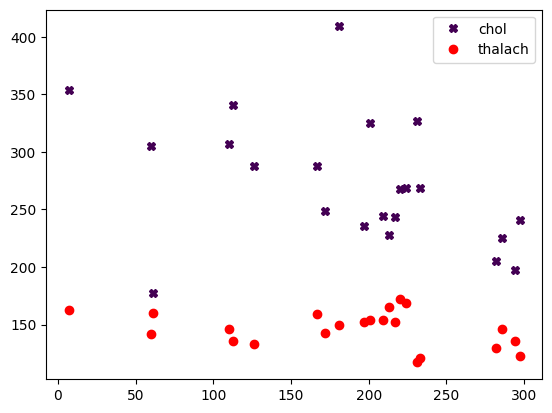

In [44]:
df3 = heart_disease[heart_disease.sex==0][['chol', 'sex', 'thalach', 'exang']]
df3custom = df3[df3.exang==1][['chol', 'sex', 'thalach', 'exang']]
cholthalachplot.df = df3custom[['chol','thalach']]
customcholthalachplot =cholthalachplot.df.plot(colormap='viridis', style=['X','ro'])
'''
This second part is reserved for future fig export
'''
fig4 = customcholthalachplot.get_figure()
plots.append(fig4)

Plot column `thal` with a pie chart.

- If you encaunter any value issues, convert values to float first.
- Display percentages on the graph.

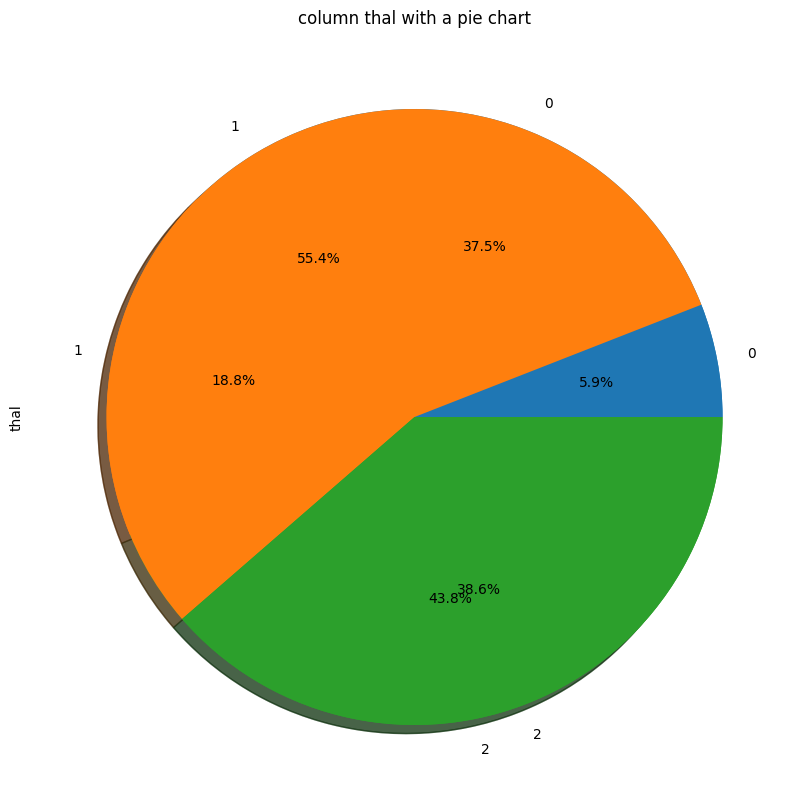

In [45]:
custom = heart_disease.fillna(heart_disease['thal'].mode()[0])
#thalplot = custom.plot.pie(y= 'thal')
custom['thal'] = pd.to_numeric(custom['thal'], errors='coerce')
data = custom.groupby([ 'thal'], sort=False).size().reset_index().rename(columns={0: 'thal'})
thalplot = data.plot.pie(y='thal', title="column thal with a pie chart", legend=False, \
                   autopct='%1.1f%%', shadow=True, startangle=0, figsize=(10, 10))
'''
This second part is reserved for future fig export
'''
fig5 = thalplot.get_figure()
plots.append(fig5)

Calculates the difference of the records with the previous records using [diff function](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.diff.html#pandas-dataframe-diff) for `thal` column. Then, plot column `thal` with a histogram.

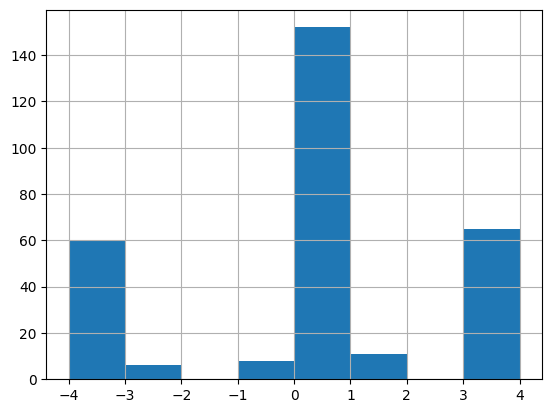

In [46]:
difference = custom['thal'].diff()
thalplot2 = difference.hist(bins=8)
'''
This second part is reserved for future fig export
'''
fig6 = thalplot2.get_figure()
plots.append(fig6)

Select `restecg`, `thalach`, `chol`, `oldpeak` columns. Plot histogram of the selected dataframe.

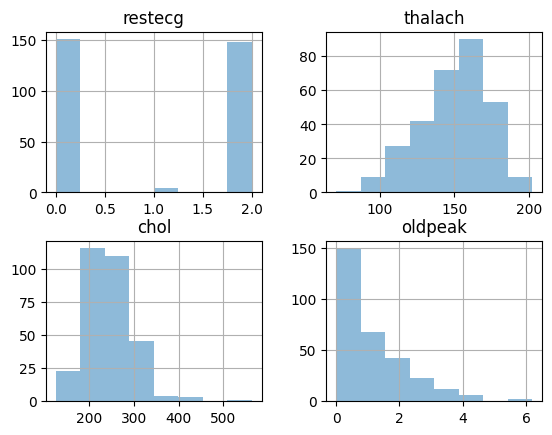

In [48]:
customdf= heart_disease[['restecg', 'thalach', 'chol', 'oldpeak']]
customdfplot = customdf.hist(bins=8, alpha=0.5)
'''
This second part is reserved for future fig export
'''
fig7 = customdfplot
plots.append(fig7)

Select `thalach` and `chol` columns. Plot a box plot of the selected dataframe.

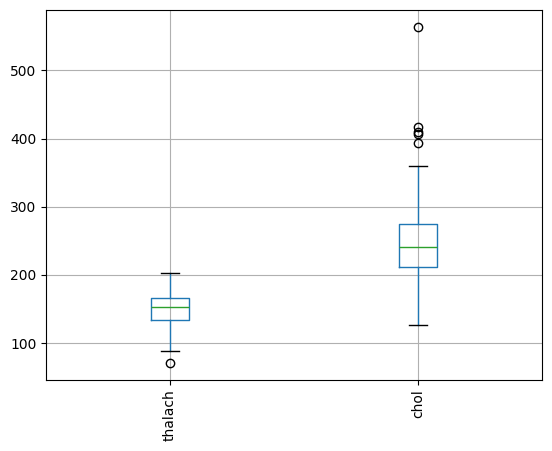

In [49]:
cols= ['thalach', 'chol']
customdfplot2 = customdf.boxplot(column=cols, rot=90)
'''
This second part is reserved for future fig export
'''
fig8 = customdfplot2.get_figure()
plots.append(fig8)

## Save Figures

Save all figures so far to `data` folder.

Hint: Make a function to save figures. Collect all figures in a list and save figures from the list.

In [50]:
figures = ['sexplot', 'cpplot', 'cholthalachplot', 'customcholthalachplot', 'thalplot', 'thalplot2', 'customdfplot', 'customdfplot2']
def plotting():
    '''for i in enumerate (figures):
        plots[i].savefig(u'data/'+i+'.png', format = "png")'''
    plots[0].savefig(u'data/'+figures[0]+'.png', format = "png")
    plots[1].savefig(u'data/'+figures[1]+'.png', format = "png")
    plots[2].savefig(u'data/'+figures[2]+'.png', format = "png")
    plots[3].savefig(u'data/'+figures[3]+'.png', format = "png")
    plots[4].savefig(u'data/'+figures[4]+'.png', format = "png")
    plots[5].savefig(u'data/'+figures[5]+'.png', format = "png")
    plots[6].savefig(u'data/'+figures[6]+'.png', format = "png")


In [51]:
plotting()

AttributeError: 'numpy.ndarray' object has no attribute 'savefig'